In [1]:
import numpy as np
from qutip import *
from scipy.optimize import curve_fit


In [2]:
from dataclasses import dataclass, field
import numpy as np


@dataclass(slots=True)
class Params:
    """
    DRAG gate parameters for weakly-anharmonic transmon (qutrit model)
    """

    # Hilbert space
    N: int = 3

    # System parameters
    w01: float = 2*np.pi*5e9
    alpha: float = -2*np.pi*200e6   # anharmonicity

    # Pulse parameters
    omega_d: float = 2*np.pi*10e6
    wd: float = 2*np.pi*5e9
    # DRAG parameter
    beta: float | None = 0
    sigma: float = 1/6
    length: float = 115e-9

    # Decoherence
    T1: float | None = 100e-6
    Tphi: float | None = 100e-6
    
    

    @property
    def Gamma1(self):
        return 0 if self.T1 is None else 1/self.T1

    @property
    def Gamma_phi(self):
        return 0 if self.Tphi is None else 1/self.Tphi

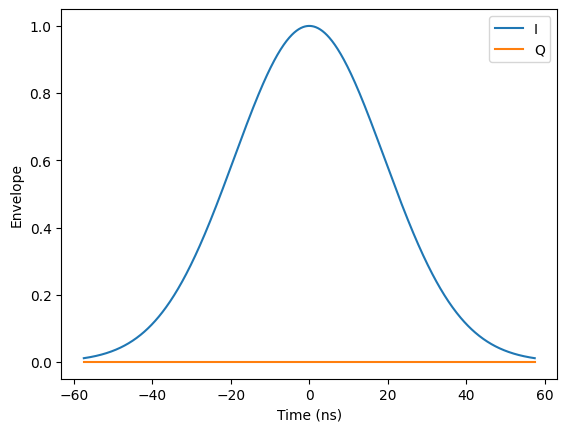

In [3]:
from matplotlib import pyplot as plt
# from scipy.integrate import trapezoid as trapz

class DRAGPulse:

    def __init__(self,params: Params):
        self.sigma = params.sigma
        self.beta = params.beta
        self.alpha = params.alpha
        self.length = params.length


    def gaussian(self, t):
        _sigma = self.length*self.sigma
        return np.exp(-t**2/(2*_sigma**2))

    def d_gaussian(self, t):
        length = self.length
        _sigma = length*self.sigma
        alpha = self.alpha
        g = self.gaussian(t)
        return -2*t*g/_sigma**2*length

    def envelope(self, t):
        return self.gaussian(t) + 1j*self.beta*self.d_gaussian(t)
    
    
    
params = Params()
drag_pulse = DRAGPulse(params)
ts = np.linspace(-drag_pulse.length/2, drag_pulse.length/2, 1000)
plt.plot(ts*1e9, drag_pulse.envelope(ts).real, label="I")
plt.plot(ts*1e9, drag_pulse.envelope(ts).imag, label="Q")
plt.xlabel("Time (ns)")
plt.ylabel("Envelope")
plt.legend()

In [9]:
class Hamiltonian:
    _a = destroy(3)

    def __init__(self, params: Params):
        self.N = params.N
        self.params = params
        self.pulse = DRAGPulse(params)

    def H0(self):
        a = destroy(self.N)

        w01 = self.params.w01
        wd = self.params.wd
        detuning = w01 - wd
        alpha = self.params.alpha
        H0 = detuning*a.dag()*a + alpha/2*a.dag()*a.dag()*a*a
        return H0

    def H1(self):
        omega_d = self.params.omega_d
        a = destroy(self.N)
        return omega_d*(a + a.dag())
        
        
        return omega_d*(a+a.dag())

    def H(self):
        self.envelope = self.pulse.envelope
        return [self.H0(), [self.H1(), self.envelope]]
    
    


/var/folders/5l/mx_yndbx4sq978lx9ht2346r0000gn/T/ipykernel_44534/1775902520.py:63: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


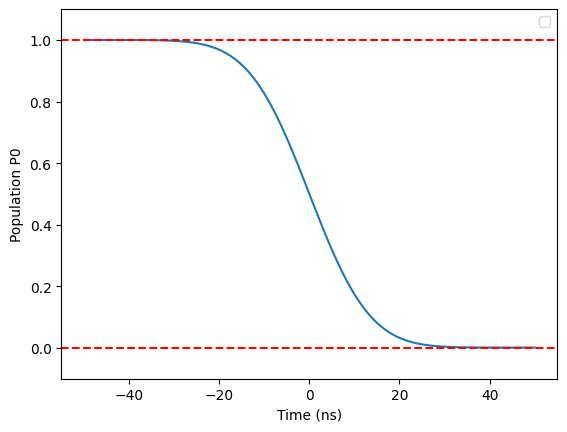

Quantum object: dims=[[[3], [3]], [[3], [3]]], shape=(9, 9), type='super', dtype=Dense, isherm=False
Qobj data =
[[ 1.13674683e-03+2.08566028e-18j -2.52021207e-02-5.67244549e-04j
  -1.16341969e-05-1.94323144e-06j -2.52021207e-02+5.67244549e-04j
   9.98863161e-01+1.10429326e-18j  4.61861811e-04+6.63144096e-05j
  -1.16341969e-05+1.94323144e-06j  4.61861811e-04-6.63144096e-05j
   9.99008456e-04-1.02116018e-19j]
 [-2.52012792e-02-7.40594146e-04j -6.36427854e-04-2.07195834e-05j
   1.11971680e-05+1.28440787e-05j  9.98363262e-01-7.94490819e-06j
   2.52030259e-02+3.93513480e-04j -7.97506082e-06-4.64128082e-04j
   4.62090176e-04-6.66168613e-05j  1.16690639e-05-1.28959392e-05j
  -1.70322212e-06+3.45959439e-04j]
 [-1.16150288e-05-2.02439364e-06j  3.24150031e-08+1.17186352e-05j
   2.90328228e-03-2.50125999e-02j  4.62089574e-04+6.66137112e-05j
  -8.27442563e-06-4.63983122e-04j -1.00023029e-01+9.92066289e-01j
   2.18321996e-07+3.11504746e-13j -3.40385746e-08-2.19474753e-07j
   1.98782596e-05+4.66008

In [10]:
def simulate_drag_population(params: Params):
    pulse = DRAGPulse(params)
    ts = np.linspace(-pulse.length/2, pulse.length/2, 1000)
    H = Hamiltonian(params).H()

    psi0 = basis(params.N, 0)
    
    c_opts = []
    if params.T1 is not None:
        c_opts.append(np.sqrt(params.Gamma1)*destroy(params.N))
    if params.Tphi is not None:
        c_opts.append(np.sqrt(params.Gamma_phi)*num(params.N))

    result = mesolve(H, psi0, ts, c_ops=c_opts)
    states = result.states

    return ts, states


def calculate_fidelity(u, target):
    fidelity = process_fidelity(u, target)
    return fidelity


def gate_propagator(params: Params):
    pulse = DRAGPulse(params)
    ts = np.linspace(-pulse.length/2, pulse.length/2, 1000)
    H = Hamiltonian(params).H()
    
    c_opts = []
    if params.T1 is not None:
        c_opts.append(np.sqrt(params.Gamma1)*destroy(params.N))
    if params.Tphi is not None:
        c_opts.append(np.sqrt(params.Gamma_phi)*num(params.N))
    
    U = propagator(H, ts, c_ops=c_opts)[-1]
    return U


params = Params()
params.length = 100e-9
params.omega_d = 2*np.pi*12e6/2

ts, pops = simulate_drag_population(params)


def measure_operators(N):
    P0 = basis(N, 0)*basis(N, 0).dag()
    P1 = basis(N, 1)*basis(N, 1).dag()
    P2 = basis(N, 2)*basis(N, 2).dag()
    return P0, P1, P2


P0,P1,P2 = measure_operators(params.N)

pops = expect(P0, pops)

# plt.plot(ts*1e9, drag_pulse.envelope(ts).real, label="I")
# plt.plot(ts*1e9, drag_pulse.envelope(ts).imag, label="Q")
plt.plot(ts*1e9, pops)
plt.xlabel("Time (ns)")
plt.ylabel("Population P0")
plt.legend()
plt.ylim(-0.1, 1.1)
plt.axhline(0, color="red", linestyle="--")
plt.axhline(1, color="red", linestyle="--")

plt.show()

U = gate_propagator(params)

print(U)

X = Qobj([[0, -1, 0],
          [-1,  0, 0],
          [0,   0, 1]])

# X = sigmax()

X_super = to_super(X)

fidelity1 = calculate_fidelity(U, X_super)

print(f"Fidelity: {fidelity1:.6f}")

Rabi frequency: 3.00 MHz


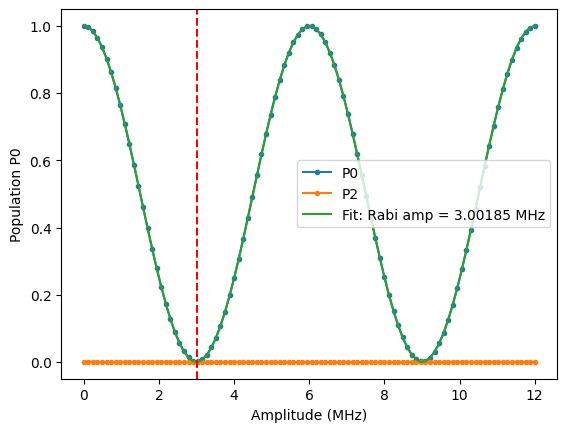

In [14]:
class RabiExperiment:
    def __init__(self, params: Params):
        self.params = params
        self.omega_d = self.params.omega_d
        self.pulse = DRAGPulse(params=self.params)
        self.amplitudes = np.linspace(0, self.omega_d, 100)
        self.n_reps = 1
        self.results = {'P0': [], 'P1': [], 'P2': []}
        self.ideal_rabi_amp = None

    def run(self) -> None:
        for amp in self.amplitudes:
            self.params.omega_d = amp*self.n_reps

            scaled_pulse = DRAGPulse(params=self.params)

            H = Hamiltonian(self.params).H()

            ts = np.linspace(-scaled_pulse.length/2,
                             scaled_pulse.length/2, 1000)

            # us = propagator(H, ts)

            # u = us[-1]

            ts, states = simulate_drag_population(self.params)
            P0,P1,P2 = measure_operators(self.params.N)

            self.results['P0'].append(expect(P0, states)[-1])
            self.results['P1'].append(expect(P1, states)[-1])
            self.results['P2'].append(expect(P2, states)[-1])

    def analysis(self):

        def fit_func(x, A, B, C=0, D=0):
            return 0.5*np.cos(0.5/B*x+0) + 0.5
        
        
        PB = 2.5e6*115e-9/self.params.length/self.params.sigma/2

        p0 = [0.5, PB, 0, 0]
        bounds = ([0, 0, 0, -np.inf], [1, 50e6*2*np.pi, np.pi, 1])
        args = curve_fit(
            fit_func,
            self.amplitudes,
            self.results['P0'],
            p0=p0,
            bounds=bounds
        )

        A, B, C, D = args[0]
        print(f"Rabi frequency: {B/1e6:.2f} MHz")
        plt.plot(self.amplitudes/2/np.pi/1e6,
                self.results['P0'] , marker='.', label="P0")
        plt.plot(self.amplitudes/2/np.pi/1e6,self.results['P2'] , marker='.', label="P2")
        plt.plot(self.amplitudes/2/np.pi/1e6, fit_func(self.amplitudes,
                A, B, C, D), label=f"Fit: Rabi amp = {B/1e6:.5f} MHz")

        plt.plot()
        plt.axvline(B/1e6, color='red', linestyle='--')
        plt.xlabel("Amplitude (MHz)")
        plt.ylabel("Population P0")
        plt.legend()
        plt.show()
        
        self.ideal_rabi_amp = B
        


params = Params()
params.beta = 0
params.length = 200e-9
params.omega_d = 2*np.pi*12e6


rabi_exp = RabiExperiment(params)
rabi_exp.run()

rabi_exp.analysis()

0.5102660595240364

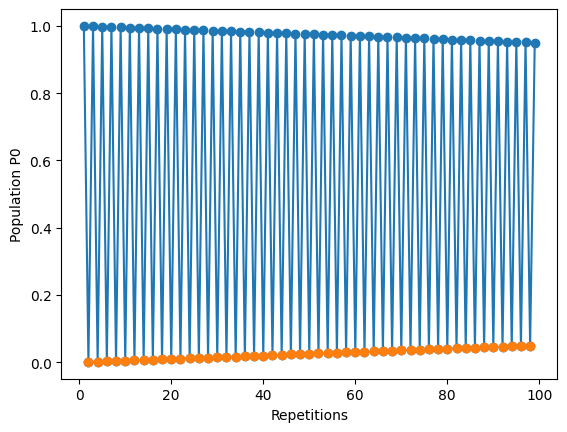

In [36]:
params.omega_d = 6e6*2*np.pi
params.length = 100e-9
U = gate_propagator(params)


psi0 = basis(params.N, 0)

rho = basis(params.N, 0)*basis(params.N, 0).dag()
rho = operator_to_vector(rho)
U = gate_propagator(params)

reps = range(1,100)
pops = []
for _ in reps:
    pops.append(expect(P0, vector_to_operator(rho)))
    rho = U*rho
plt.plot(reps, pops, marker='o')
plt.plot(reps[1:-1:2], pops[1:-1:2], marker='o')
plt.ylabel("Population P0")
plt.xlabel("Repetitions")

# X_channel = spre(X) * spost(X)
process_fidelity(X,U)

# U

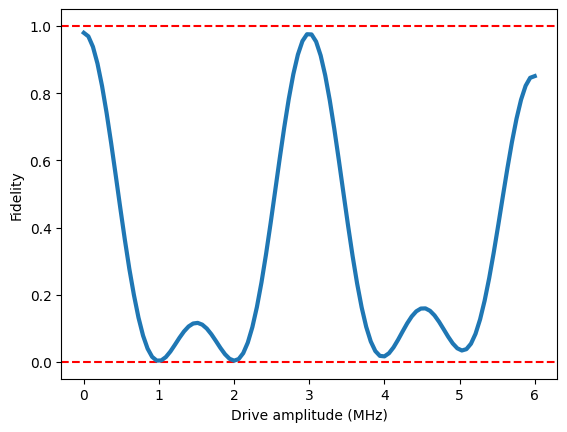

min fidelity: 0.0037029588447498162


In [32]:
max_amp = 6.0e6*2*np.pi*1
params.length = 200e-9

amps = np.linspace(0, max_amp, 100)
fidelities = []

X = Qobj(
    [[0, 1, 0],
     [1, 0, 0],
     [0, 0, 1]]
)

# X = spre(X) * spost(X)

for a in amps:
    params.omega_d = a
    U = gate_propagator(params)
    fidelities.append(process_fidelity(U*U*U*U,qeye(3)))

plt.axhline(1, color='red', linestyle='--')
plt.axhline(0, color='red', linestyle='--')
plt.plot(amps/2/np.pi/1e6, fidelities,linewidth=3)
plt.ylabel("Fidelity")
plt.xlabel("Drive amplitude (MHz)")
plt.show()

print('min fidelity:', min(fidelities))